<a href="https://colab.research.google.com/github/pankajkumar8709/Machine-Learning-projects/blob/main/RandomForestRegressor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [60]:
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path=kagglehub.dataset_download('nileshthonte/ols-regression-challenge')

100%|██████████| 300k/300k [00:00<00:00, 65.6MB/s]

Extracting files...


In [3]:
import os
os.listdir(path)

['cancer_reg.csv']

In [4]:
df = pd.read_csv(path + '/cancer_reg.csv', encoding='latin1')

In [5]:
df

,avgAnnCount,avgDeathsPerYear,TARGET_deathRate,incidenceRate,medIncome,popEst2015,povertyPercent,studyPerCap,binnedInc,MedianAge,...,PctPrivateCoverageAlone,PctEmpPrivCoverage,PctPublicCoverage,PctPublicCoverageAlone,PctWhite,PctBlack,PctAsian,PctOtherRace,PctMarriedHouseholds,BirthRate
0,1397.000000,469,164.9,489.800000,61898,260131,11.2,499.748204,"(61494.5, 125635]",39.3,...,NaN,41.6,32.9,14.0,81.780529,2.594728,4.821857,1.843479,52.856076,6.118831
1,173.000000,70,161.3,411.600000,48127,43269,18.6,23.111234,"(48021.6, 51046.4]",33.0,...,53.8,43.6,31.1,15.3,89.228509,0.969102,2.246233,3.741352,45.372500,4.333096
2,102.000000,50,174.7,349.700000,49348,21026,14.6,47.560164,"(48021.6, 51046.4]",45.0,...,43.5,34.9,42.1,21.1,90.922190,0.739673,0.465898,2.747358,54.444868,3.729488
3,427.000000,202,194.8,430.400000,44243,75882,17.1,342.637253,"(42724.4, 45201]",42.8,...,40.3,35.0,45.3,25.0,91.744686,0.782626,1.161359,1.362643,51.021514,4.603841
4,57.000000,26,144.4,350.100000,49955,10321,12.5,0.000000,"(48021.6, 51046.4]",48.3,...,43.9,35.1,44.0,22.7,94.104024,0.270192,0.665830,0.492135,54.027460,6.796657
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3042,1962.667684,15,149.6,453.549422,46961,6343,12.4,0.000000,"(45201, 48021.6]",44.2,...,54.9,44.6,31.7,13.2,90.280811,3.837754,0.327613,1.700468,51.063830,7.773512
3043,1962.667684,43,150.1,453.549422,48609,37118,18.8,377.175494,"(48021.6, 51046.4]",30.4,...,53.3,48.6,28.8,17.7,75.706245,2.326771,4.044920,14.130288,52.007937,8.186470
3044,1962.667684,46,153.9,453.549422,51144,34536,15.0,1968.959926,"(51046.4, 54545.6]",30.9,...,52.6,47.8,26.6,16.8,87.961629,2.313188,1.316472,5.680705,55.153949,7.809192
3045,1962.667684,52,175.0,453.549422,50745,25609,13.3,0.000000,"(48021.6, 51046.4]",39.0,...,56.3,49.6,29.5,14.0,92.905681,1.176562,0.244632,2.131790,58.484232,7.582938


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3047 entries, 0 to 3046
Data columns (total 34 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   avgAnnCount              3047 non-null   float64
 1   avgDeathsPerYear         3047 non-null   int64  
 2   TARGET_deathRate         3047 non-null   float64
 3   incidenceRate            3047 non-null   float64
 4   medIncome                3047 non-null   int64  
 5   popEst2015               3047 non-null   int64  
 6   povertyPercent           3047 non-null   float64
 7   studyPerCap              3047 non-null   float64
 8   binnedInc                3047 non-null   object 
 9   MedianAge                3047 non-null   float64
 10  MedianAgeMale            3047 non-null   float64
 11  MedianAgeFemale          3047 non-null   float64
 12  Geography                3047 non-null   object 
 13  AvgHouseholdSize         3047 non-null   float64
 14  PercentMarried          

In [7]:
df.isnull().sum()

,0
avgAnnCount,0
avgDeathsPerYear,0
TARGET_deathRate,0
incidenceRate,0
medIncome,0
popEst2015,0
povertyPercent,0
studyPerCap,0
binnedInc,0
MedianAge,0


In [8]:
df.sample(5)

,avgAnnCount,avgDeathsPerYear,TARGET_deathRate,incidenceRate,medIncome,popEst2015,povertyPercent,studyPerCap,binnedInc,MedianAge,...,PctPrivateCoverageAlone,PctEmpPrivCoverage,PctPublicCoverage,PctPublicCoverageAlone,PctWhite,PctBlack,PctAsian,PctOtherRace,PctMarriedHouseholds,BirthRate
2733,186.0,95,142.1,269.9,32366,71474,33.1,307.804237,"[22640, 34218.1]",33.4,...,24.7,22.4,50.8,38.8,23.240530,0.612833,0.427042,1.056514,40.001038,6.518302
543,102.0,51,213.5,442.5,34916,16779,23.0,59.598307,"(34218.1, 37413.8]",41.1,...,35.5,30.9,47.1,27.7,97.298726,0.898467,0.076340,0.035234,47.864397,5.841924
674,60.0,25,161.7,461.2,42745,8543,14.9,0.000000,"(42724.4, 45201]",47.6,...,50.0,35.9,36.2,15.8,87.529219,0.070126,0.502571,0.607761,54.790097,6.866667
232,57.0,22,176.2,452.4,42204,8908,19.7,0.000000,"(40362.7, 42724.4]",43.7,...,53.0,43.7,35.6,17.9,66.492380,28.824118,2.180443,0.645233,50.226087,8.755130
2440,129.0,55,186.9,438.7,42125,21353,18.9,0.000000,"(40362.7, 42724.4]",45.6,...,NaN,35.5,38.7,19.5,68.941498,26.591989,0.545959,2.795689,56.322382,5.057136


In [49]:
from sklearn.model_selection import train_test_split

from sklearn.ensemble import VotingClassifier,BaggingClassifier,RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier,RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report,r2_score

In [10]:
!pip install SimpleImputer,StandardScaler

ERROR: Invalid requirement: 'SimpleImputer,StandardScaler': Expected end or semicolon (after name and no valid version specifier)
    SimpleImputer,StandardScaler
                 ^


In [24]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.impute import SimpleImputer

In [14]:
df.columns

Index(['avgAnnCount', 'avgDeathsPerYear', 'TARGET_deathRate', 'incidenceRate',
       'medIncome', 'popEst2015', 'povertyPercent', 'studyPerCap', 'binnedInc',
       'MedianAge', 'MedianAgeMale', 'MedianAgeFemale', 'Geography',
       'AvgHouseholdSize', 'PercentMarried', 'PctNoHS18_24', 'PctHS18_24',
       'PctSomeCol18_24', 'PctBachDeg18_24', 'PctHS25_Over',
       'PctBachDeg25_Over', 'PctEmployed16_Over', 'PctUnemployed16_Over',
       'PctPrivateCoverage', 'PctPrivateCoverageAlone', 'PctEmpPrivCoverage',
       'PctPublicCoverage', 'PctPublicCoverageAlone', 'PctWhite', 'PctBlack',
       'PctAsian', 'PctOtherRace', 'PctMarriedHouseholds', 'BirthRate'],
      dtype='object')

In [15]:
x_train,x_test,y_train,y_test=train_test_split(df.drop(columns=['TARGET_deathRate']),df['TARGET_deathRate'],test_size=0.2,random_state=42)

In [17]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((2437, 33), (610, 33), (2437,), (610,))

In [23]:
df['Geography'].nunique()

3047

In [34]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

geo_encoded_train= ohe.fit_transform(x_train[['Geography']])
geo_encoded_test= ohe.transform(x_test[['Geography']])

In [33]:
num_cols = x_train.select_dtypes(include=['int64', 'float64']).columns
num_cols

Index(['avgAnnCount', 'avgDeathsPerYear', 'incidenceRate', 'medIncome',
       'popEst2015', 'povertyPercent', 'studyPerCap', 'MedianAge',
       'MedianAgeMale', 'MedianAgeFemale', 'AvgHouseholdSize',
       'PercentMarried', 'PctNoHS18_24', 'PctHS18_24', 'PctSomeCol18_24',
       'PctBachDeg18_24', 'PctHS25_Over', 'PctBachDeg25_Over',
       'PctEmployed16_Over', 'PctUnemployed16_Over', 'PctPrivateCoverage',
       'PctPrivateCoverageAlone', 'PctEmpPrivCoverage', 'PctPublicCoverage',
       'PctPublicCoverageAlone', 'PctWhite', 'PctBlack', 'PctAsian',
       'PctOtherRace', 'PctMarriedHouseholds', 'BirthRate'],
      dtype='object')

In [29]:
from sklearn.impute import SimpleImputer

num_cols = x_train.select_dtypes(include=['int64', 'float64']).columns

imp = SimpleImputer(strategy='mean')

x_train_trf = imp.fit_transform(x_train[num_cols])
x_test_trf = imp.transform(x_test[num_cols])

In [43]:
x_train=np.concatenate((x_train_trf,geo_encoded_train),axis=1)
x_test=np.concatenate((x_test_trf,geo_encoded_test),axis=1)

In [44]:
x_train_t=pd.DataFrame(x_train,columns=num_cols.tolist()+list(ohe.get_feature_names_out()))
x_test_t=pd.DataFrame(x_test,columns=num_cols.tolist()+list(ohe.get_feature_names_out()))

 #PctBachDeg25_Over vs TARGET_deathRate

<Axes: xlabel='PctBachDeg25_Over', ylabel='TARGET_deathRate'>

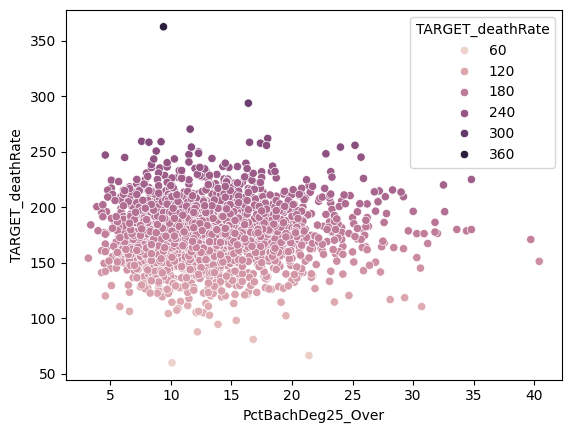

In [58]:
sns.scatterplot(x=x_train_t['PctBachDeg25_Over'],y=y_train,hue=y_train)

In [40]:
x_train.shape

(2437, 2468)

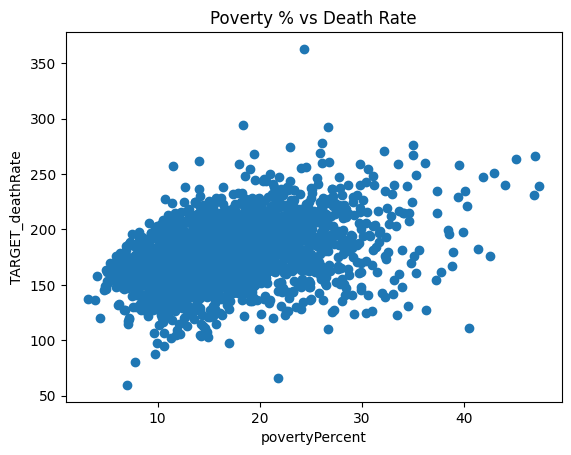

In [61]:
plt.scatter(x_train_t['povertyPercent'], y_train)
plt.xlabel('povertyPercent')
plt.ylabel('TARGET_deathRate')
plt.title('Poverty % vs Death Rate')
plt.show()

In [50]:
rfr=RandomForestRegressor()
rfr.fit(x_train_t,y_train)



RandomForestRegressor()

In [51]:
y_pred=rfr.predict(x_test_t)
r2_score(y_test,y_pred)


0.5531312464390423

In [52]:
from sklearn.tree import DecisionTreeRegressor
dt=DecisionTreeRegressor()
dt.fit(x_train_t,y_train)

DecisionTreeRegressor()

In [53]:
y_pred=dt.predict(x_test_t)
r2_score(y_test,y_pred)

0.1872351895032297

In [54]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train_t,y_train)

LinearRegression()

In [55]:
y_pred=lr.predict(x_test_t)
r2_score(y_test,y_pred)

0.49434149462613575

In [62]:
rfr=RandomForestRegressor(n_estimators=250)
rfr.fit(x_train_t,y_train)



RandomForestRegressor(n_estimators=250)

In [63]:
y_pred=rfr.predict(x_test_t)
r2_score(y_test,y_pred)

0.5513988852360376

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

rfr = RandomForestRegressor(random_state=42, n_jobs=-1)

param_grid = {
    'n_estimators': [200, 250],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    rfr,
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid.fit(x_train_t, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)